# TIM Compression and Squeeze-Out Model

This notebook evaluates two TIM interfaces in a stacked assembly:

- **Die interface:** Parker Chomerics GEL 8010
- **Copper-spreader interface:** Parker Chomerics GEL 75

The model calculates average pressure, compression strain, retained TIM volume, nominal squeeze-out volume, and equivalent final spread area.

> **Scope:** This is a geometric and average-pressure model. It does not prove that a specified pressure will produce a specified final bondline thickness.


## Governing equations

For each interface:

\[
P = \frac{F}{A}
\]

\[
\epsilon_c = \frac{t_0 - t_f}{t_0}
\]

\[
V_0 = A t_0
\]

\[
V_{\text{inside}} = A t_f
\]

Assuming approximate volume conservation:

\[
V_{\text{squeeze}} = A(t_0-t_f)
\]

\[
A_{\text{equivalent}} = A\frac{t_0}{t_f}
\]

\[
\lambda = \sqrt{\frac{A_{\text{equivalent}}}{A}}
\]


In [13]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 5)

output_dir = Path("figures/generated")
output_dir.mkdir(parents=True, exist_ok=True)

## Editable model inputs

Change values only in this cell for the baseline model.


In [14]:
force_lbf = 4.0

interfaces = {
    "Die — GEL 8010": {
        "area_in2": 0.300,
        "initial_thickness_in": 0.010,
        "target_thickness_in": 0.005,
        "minimum_bondline_in": 0.002,
        "thermal_conductivity_W_mK": 3.0,
    },
    "Copper spreader — GEL 75": {
        "area_in2": 1.400,
        "initial_thickness_in": 0.040,
        "target_thickness_in": 0.025,
        "minimum_bondline_in": 0.008,
        "thermal_conductivity_W_mK": 7.5,
    },
}

force_sweep_lbf = np.linspace(1.0, 10.0, 100)


In [15]:
def calculate_interface(
    force_lbf: float,
    area_in2: float,
    initial_thickness_in: float,
    final_thickness_in: float,
    minimum_bondline_in: float | None = None,
) -> dict:
    if force_lbf <= 0:
        raise ValueError("Force must be positive.")
    if area_in2 <= 0:
        raise ValueError("Area must be positive.")
    if initial_thickness_in <= 0:
        raise ValueError("Initial thickness must be positive.")
    if final_thickness_in <= 0:
        raise ValueError("Final thickness must be positive.")
    if final_thickness_in > initial_thickness_in:
        raise ValueError("Final thickness cannot exceed initial thickness.")

    pressure_psi = force_lbf / area_in2
    compression_in = initial_thickness_in - final_thickness_in
    compression_fraction = compression_in / initial_thickness_in

    initial_volume_in3 = area_in2 * initial_thickness_in
    retained_volume_in3 = area_in2 * final_thickness_in
    displaced_volume_in3 = initial_volume_in3 - retained_volume_in3

    equivalent_final_area_in2 = initial_volume_in3 / final_thickness_in
    extra_area_in2 = equivalent_final_area_in2 - area_in2
    footprint_scale = math.sqrt(equivalent_final_area_in2 / area_in2)

    result = {
        "Pressure (psi)": pressure_psi,
        "Initial BLT (in)": initial_thickness_in,
        "Target BLT (in)": final_thickness_in,
        "Compression (in)": compression_in,
        "Compression (%)": 100 * compression_fraction,
        "Initial volume (in³)": initial_volume_in3,
        "Retained volume (in³)": retained_volume_in3,
        "Squeeze-out volume (in³)": displaced_volume_in3,
        "Squeeze-out volume (µL)": displaced_volume_in3 * 16387.064,
        "Equivalent final area (in²)": equivalent_final_area_in2,
        "Extra area (in²)": extra_area_in2,
        "Linear footprint scale": footprint_scale,
        "Linear growth (%)": 100 * (footprint_scale - 1),
    }

    if minimum_bondline_in is not None:
        result["Typical minimum BLT (in)"] = minimum_bondline_in
        result["Target above minimum?"] = final_thickness_in >= minimum_bondline_in

    return result


In [16]:
results = {
    name: calculate_interface(
        force_lbf=force_lbf,
        area_in2=values["area_in2"],
        initial_thickness_in=values["initial_thickness_in"],
        final_thickness_in=values["target_thickness_in"],
        minimum_bondline_in=values["minimum_bondline_in"],
    )
    for name, values in interfaces.items()
}

results_df = pd.DataFrame(results).T
results_df


,Pressure (psi),Initial BLT (in),Target BLT (in),Compression (in),Compression (%),Initial volume (in³),Retained volume (in³),Squeeze-out volume (in³),Squeeze-out volume (µL),Equivalent final area (in²),Extra area (in²),Linear footprint scale,Linear growth (%),Typical minimum BLT (in),Target above minimum?
Die — GEL 8010,13.33333,0.01,0.005,0.005,50.0,0.003,0.0015,0.0015,24.5806,0.6,0.3,1.41421,41.42136,0.002,True
Copper spreader — GEL 75,2.85714,0.04,0.025,0.015,37.5,0.056,0.035,0.021,344.12834,2.24,0.84,1.26491,26.49111,0.008,True


## Baseline interpretation

Under the no-load-bypass assumption, both interfaces transmit the same 4 lbf resultant force. The smaller die area therefore has the larger average pressure.

The nominal squeeze-out volume is the amount of initial TIM volume that cannot remain inside the original footprint after the target thickness is reached.


In [17]:
summary_columns = [
    "Pressure (psi)",
    "Compression (%)",
    "Squeeze-out volume (in³)",
    "Squeeze-out volume (µL)",
    "Equivalent final area (in²)",
    "Linear growth (%)",
    "Target above minimum?",
]
results_df[summary_columns]


,Pressure (psi),Compression (%),Squeeze-out volume (in³),Squeeze-out volume (µL),Equivalent final area (in²),Linear growth (%),Target above minimum?
Die — GEL 8010,13.33333,50.0,0.0015,24.5806,0.6,41.42136,True
Copper spreader — GEL 75,2.85714,37.5,0.021,344.12834,2.24,26.49111,True


In [18]:
pressure_ratio = (
    results_df.loc["Die — GEL 8010", "Pressure (psi)"]
    / results_df.loc["Copper spreader — GEL 75", "Pressure (psi)"]
)

print(f"Die-to-spreader average pressure ratio: {pressure_ratio:.3f}×")


Die-to-spreader average pressure ratio: 4.667×


## Plot 1 — Average pressure at the nominal 4 lbf load


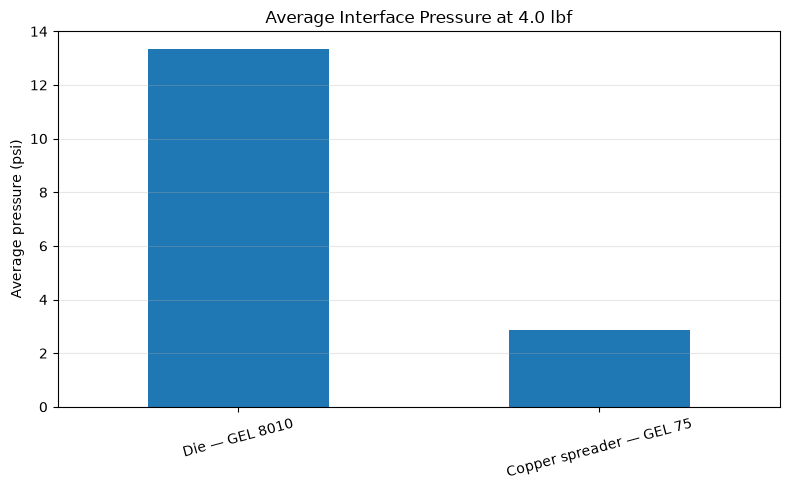

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

results_df["Pressure (psi)"].plot(kind="bar", ax=ax)

ax.set_ylabel("Average pressure (psi)")
ax.set_xlabel("")
ax.set_title(f"Average Interface Pressure at {force_lbf:.1f} lbf")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

fig.savefig(
    output_dir / "average_interface_pressure.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

## Plot 2 — Pressure sensitivity to clamp force


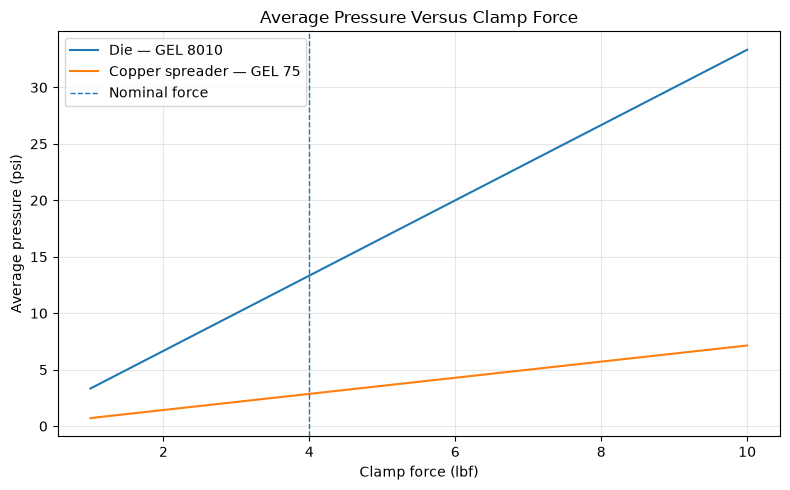

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

for name, values in interfaces.items():
    pressure = force_sweep_lbf / values["area_in2"]
    ax.plot(force_sweep_lbf, pressure, label=name)

ax.axvline(
    force_lbf,
    linestyle="--",
    linewidth=1,
    label="Nominal force",
)

ax.set_xlabel("Clamp force (lbf)")
ax.set_ylabel("Average pressure (psi)")
ax.set_title("Average Pressure Versus Clamp Force")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

fig.savefig(
    output_dir / "pressure_vs_force.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

## Plot 3 — Initial and target bondline thickness


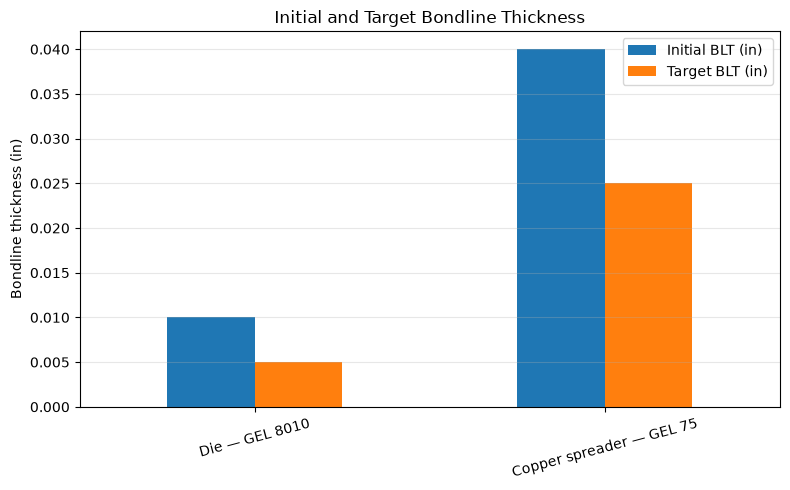

In [21]:
thickness_df = pd.DataFrame(
    {
        "Initial BLT (in)": {
            name: values["initial_thickness_in"]
            for name, values in interfaces.items()
        },
        "Target BLT (in)": {
            name: values["target_thickness_in"]
            for name, values in interfaces.items()
        },
    }
)

fig, ax = plt.subplots(figsize=(8, 5))

thickness_df.plot(kind="bar", ax=ax)

ax.set_ylabel("Bondline thickness (in)")
ax.set_xlabel("")
ax.set_title("Initial and Target Bondline Thickness")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

fig.savefig(
    output_dir / "bondline_thickness.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

## Plot 4 — Retained and nominal squeeze-out volume


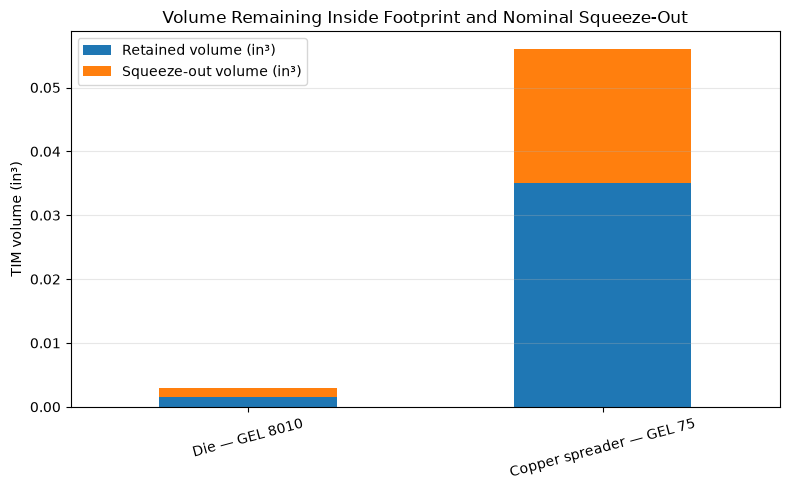

In [22]:
volume_df = results_df[
    ["Retained volume (in³)", "Squeeze-out volume (in³)"]
]

fig, ax = plt.subplots(figsize=(8, 5))

volume_df.plot(
    kind="bar",
    stacked=True,
    ax=ax,
)

ax.set_ylabel("TIM volume (in³)")
ax.set_xlabel("")
ax.set_title(
    "Volume Remaining Inside Footprint and Nominal Squeeze-Out"
)
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

fig.savefig(
    output_dir / "tim_volume.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

## Optional thermal-resistance estimate

A one-dimensional bulk conduction estimate is:

\[
R_{\mathrm{TIM}} = \frac{t}{kA}
\]

This excludes contact resistance, spreading resistance, voids, surface roughness, and nonuniform bondline thickness.


In [23]:
INCH_TO_M = 0.0254
IN2_TO_M2 = INCH_TO_M ** 2

thermal_rows = []

for name, values in interfaces.items():
    t_m = values["target_thickness_in"] * INCH_TO_M
    area_m2 = values["area_in2"] * IN2_TO_M2
    k = values["thermal_conductivity_W_mK"]
    r_k_per_w = t_m / (k * area_m2)

    thermal_rows.append(
        {
            "Interface": name,
            "Target BLT (in)": values["target_thickness_in"],
            "Thermal conductivity (W/m-K)": k,
            "Bulk TIM resistance (K/W)": r_k_per_w,
        }
    )

thermal_df = pd.DataFrame(thermal_rows).set_index("Interface")
thermal_df


,Target BLT (in),Thermal conductivity (W/m-K),Bulk TIM resistance (K/W)
Interface,,,
Die — GEL 8010,0.005,3.0,0.21872
Copper spreader — GEL 75,0.025,7.5,0.09374


## Experimental data workflow

Record test data in:

```text
data/experimental_results.csv
```

After collecting repeated measurements, load them below and compare measured final bondline thickness with calculated average pressure.


In [24]:
experimental_path = Path("data/experimental_results.csv")

if experimental_path.exists():
    experimental_df = pd.read_csv(experimental_path)
    display(experimental_df.head())
else:
    print("Experimental data file not found.")


,trial_id,date,applied_force_lbf,die_initial_blt_in,die_final_blt_in,spreader_initial_blt_in,spreader_final_blt_in,assembly_temperature_C,dwell_time_s,notes


## Model limitations

- The model uses average pressure, not local contact pressure.
- Gel flow is time-, temperature-, geometry-, and rate-dependent.
- Large compression is not well represented by small-strain linear elasticity.
- Poisson's ratio alone cannot predict squeeze-out.
- The final bondline thickness must be validated experimentally unless material-specific compression data are available.
